In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report)
from sklearn.preprocessing import StandardScaler

In [2]:
# Cargar los datos
from google.colab import files
uploaded = files.upload()

# Intenta detectar delimitador automáticamente
try:
    df = pd.read_csv('Anexo ET_demo_round_traces_2022.csv', low_memory=False)
except pd.errors.ParserError:
    df = pd.read_csv('Anexo ET_demo_round_traces_2022.csv', sep=';', low_memory=False)

# Eliminar columna de índice innecesaria si existe
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Asignar nombres correctos a las columnas si corresponde
column_names = [
    'PlayerId', 'Map', 'Team', 'InternalTeamId', 'MatchId', 'RoundId', 'RoundWinner',
    'MatchWinner', 'Survived', 'AbnormalMatch', 'TimeAlive', 'TravelledDistance',
    'RLethalGrenadesThrown', 'RNonLethalGrenadesThrown', 'PrimaryAssaultRifle',
    'PrimarySniperRifle', 'PrimaryHeavy', 'PrimarySMG', 'PrimaryPistol', 'FirstKillTime',
    'RoundKills', 'RoundAssists', 'RoundHeadshots', 'RoundFlankKills',
    'RoundStartingEquipmentValue', 'TeamStartingEquipmentValue', 'MatchKills',
    'MatchFlankKills', 'MatchAssists', 'MatchHeadshots']

if len(df.columns) == len(column_names):
    df.columns = column_names

# Selección de características relevantes
features = [
    'TeamStartingEquipmentValue',
    'RoundStartingEquipmentValue',
    'TimeAlive',
    'TravelledDistance',
    'RoundAssists',
    'RoundHeadshots'
]

# Conversión a numérico con control
for col in features + ['MatchKills']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Total antes de imputación: {df.shape}")

# Imputación de valores faltantes con la mediana
df[features + ['MatchKills']] = df[features + ['MatchKills']].fillna(df[features + ['MatchKills']].median())

print(f"Total después de imputación: {df.shape}")

# Crear variable objetivo ajustada
umbral = 3
df['HighKills'] = (df['MatchKills'] >= umbral).astype(int)
print(df['HighKills'].value_counts())

# Dividir datos sin forzar balanceo
X = df[features]
y = df['HighKills']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Saving Anexo ET_demo_round_traces_2022.csv to Anexo ET_demo_round_traces_2022.csv
Total antes de imputación: (79157, 29)
Total después de imputación: (79157, 29)
HighKills
1    64068
0    15089
Name: count, dtype: int64


### Resultados para Árbol de Decisión:
Accuracy: 0.6482

Matriz de Confusión:
[[1680 1338]
 [4232 8582]]
### Reporte de Clasificación - Árbol de Decisión ###
              precision    recall  f1-score   support

           0       0.28      0.56      0.38      3018
           1       0.87      0.67      0.75     12814

    accuracy                           0.65     15832
   macro avg       0.57      0.61      0.57     15832
weighted avg       0.75      0.65      0.68     15832



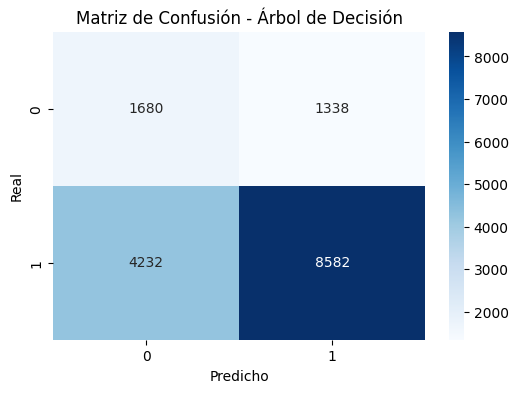

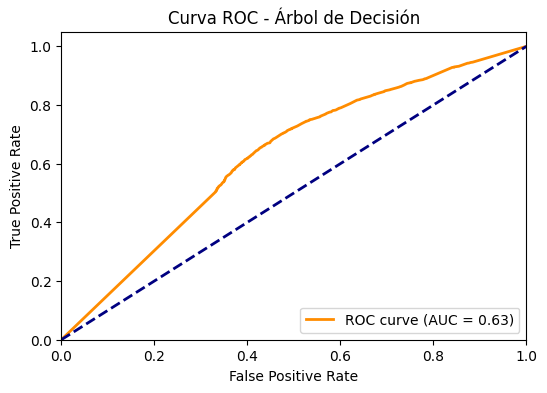

In [3]:
from sklearn.tree import DecisionTreeClassifier

# Definición del modelo Árbol de Decisión
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

# Predicciones
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Métricas
print("### Resultados para Árbol de Decisión:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}\n")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_dt))
print("### Reporte de Clasificación - Árbol de Decisión ###")
print(classification_report(y_test, y_pred_dt))
print("="*50)

# Matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_dt)
roc_auc = roc_auc_score(y_test, y_proba_dt)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Curva ROC - Árbol de Decisión')
plt.legend(loc="lower right")
plt.show()